✅ Arquivos criados em data/
   collar.csv  → 20 furos
   survey.csv  → 122 medições de orientação
   assay.csv   → 1391 intervalos de 2m

📍 Depósito: cobre (Cu%) com ouro associado (Au g/t)
📍 Zonas: Norte (728 intervalos) | Sul (663 intervalos)


In [2]:
import os

for arquivo in ['data/collar.csv', 'data/survey.csv', 'data/assay.csv']:
    tamanho = os.path.getsize(arquivo) / 1024
    df_temp = pd.read_csv(arquivo)
    print(f"{arquivo:25s} → {len(df_temp):4d} linhas | {tamanho:.1f} KB")

data/collar.csv           →   20 linhas | 1.4 KB
data/survey.csv           →  122 linhas | 2.8 KB
data/assay.csv            → 1391 linhas | 43.7 KB


In [3]:
assay = pd.read_csv('data/assay.csv')

print("=== PRIMEIRAS LINHAS ===")
print(assay.head(8))

print("\n=== ESTATÍSTICAS DE TEOR DE COBRE ===")
print(assay['Cu_pct'].describe().round(3))

print("\n=== INTERVALOS POR ZONA ===")
print(assay.groupby('zone')['Cu_pct'].agg(['count','mean','max']).round(3))

=== PRIMEIRAS LINHAS ===
     BHID  FROM  TO  Cu_pct  Au_gpt   zone
0  BH-001     0   2   0.165  0.0407  Norte
1  BH-001     2   4   0.728  0.0635  Norte
2  BH-001     4   6   0.870  0.0925  Norte
3  BH-001     6   8  -0.567  0.0326  Norte
4  BH-001     8  10   0.376  0.0792  Norte
5  BH-001    10  12   0.060  0.0269  Norte
6  BH-001    12  14   0.681  0.0211  Norte
7  BH-001    14  16   0.619  0.0210  Norte

=== ESTATÍSTICAS DE TEOR DE COBRE ===
count    1350.000
mean        0.723
std         0.865
min        -2.837
25%         0.247
50%         0.420
75%         0.914
max         9.067
Name: Cu_pct, dtype: float64

=== INTERVALOS POR ZONA ===
       count   mean    max
zone                      
Norte    712  0.741  7.097
Sul      638  0.702  9.067


In [4]:
assay = pd.read_csv('data/assay.csv')

total = len(assay)
nulos    = assay['Cu_pct'].isnull().sum()
negativos = (assay['Cu_pct'] < 0).sum()
validos  = total - nulos - negativos

print(f"Total de intervalos : {total}")
print(f"Valores nulos (NaN) : {nulos}  ({nulos/total*100:.1f}%)")
print(f"Teores negativos    : {negativos}  ({negativos/total*100:.1f}%)")
print(f"Valores válidos     : {validos} ({validos/total*100:.1f}%)")
print()
# Ver os intervalos negativos
print("=== INTERVALOS COM TEOR NEGATIVO ===")
print(assay[assay['Cu_pct'] < 0][['BHID','FROM','TO','Cu_pct']].head(10))

Total de intervalos : 1391
Valores nulos (NaN) : 41  (2.9%)
Teores negativos    : 36  (2.6%)
Valores válidos     : 1314 (94.5%)

=== INTERVALOS COM TEOR NEGATIVO ===
       BHID  FROM   TO  Cu_pct
3    BH-001     6    8  -0.567
68   BH-001   136  138  -0.206
160  BH-002   160  162  -0.342
194  BH-003    40   42  -1.682
301  BH-004    92   94  -0.936
312  BH-004   114  116  -0.226
343  BH-004   176  178  -0.281
350  BH-005     0    2  -0.698
361  BH-005    22   24  -0.149
397  BH-005    94   96  -0.661


In [5]:
# rode isso antes dos exercícios 2, 3 e 4
validos = assay[assay['Cu_pct'] >= 0].dropna(subset=['Cu_pct'])
print(f"Dados válidos carregados: {len(validos)} intervalos")

Dados válidos carregados: 1314 intervalos


In [6]:
# Só com dados válidos
validos = assay[assay['Cu_pct'] >= 0].dropna(subset=['Cu_pct'])

print("=== ESTATÍSTICAS POR ZONA (dados válidos) ===")
stats = validos.groupby('zone')['Cu_pct'].agg([
    ('intervalos', 'count'),
    ('média',      'mean'),
    ('mediana',    'median'),
    ('desvio',     'std'),
    ('mínimo',     'min'),
    ('máximo',     'max'),
    ('p90',        lambda x: x.quantile(0.9))
]).round(3)
print(stats)

print()
print("=== TEOR MÉDIO DE OURO POR ZONA ===")
print(validos.groupby('zone')['Au_gpt'].mean().round(4))

=== ESTATÍSTICAS POR ZONA (dados válidos) ===
       intervalos  média  mediana  desvio  mínimo  máximo    p90
zone                                                            
Norte         691  0.784    0.463   0.806   0.060   7.097  1.851
Sul           623  0.738    0.414   0.865   0.053   9.067  1.725

=== TEOR MÉDIO DE OURO POR ZONA ===
zone
Norte    0.1585
Sul      0.1374
Name: Au_gpt, dtype: float64


In [7]:
ranking = validos.groupby('BHID')['Cu_pct'].agg(
    intervalos='count',
    teor_medio='mean',
    teor_max='max'
).round(3).sort_values('teor_medio', ascending=False)

print("=== TOP 10 FUROS MAIS RICOS ===")
print(ranking.head(10))

# Qual zona domina o ranking?
top10 = ranking.head(10).index.tolist()
zonas_top10 = validos[validos['BHID'].isin(top10)].groupby('zone').size()
print(f"\nZonas dos top 10 furos:")
print(zonas_top10)

=== TOP 10 FUROS MAIS RICOS ===
        intervalos  teor_medio  teor_max
BHID                                    
BH-013          41       1.187     5.388
BH-005          62       0.994     3.994
BH-009          65       0.919     6.504
BH-014          58       0.912     3.269
BH-011          59       0.902     3.632
BH-007          50       0.886     3.054
BH-012          52       0.883     4.225
BH-006          50       0.815     4.966
BH-017          70       0.787     7.097
BH-004          88       0.776     3.682

Zonas dos top 10 furos:
zone
Norte    349
Sul      246
dtype: int64


In [8]:
print("=== ANÁLISE DE TEOR DE CORTE ===")
print(f"{'Cut-off (Cu%)':15} {'Intervalos':>12} {'% do total':>12} {'Teor médio':>12}")
print("-" * 55)

for cutoff in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5]:
    acima = validos[validos['Cu_pct'] >= cutoff]
    pct   = len(acima) / len(validos) * 100
    media = acima['Cu_pct'].mean()
    print(f"{cutoff:<15.1f} {len(acima):>12} {pct:>11.1f}% {media:>11.3f}%")

=== ANÁLISE DE TEOR DE CORTE ===
Cut-off (Cu%)     Intervalos   % do total   Teor médio
-------------------------------------------------------
0.1                     1300        98.9%       0.770%
0.2                     1129        85.9%       0.862%
0.3                      890        67.7%       1.027%
0.5                      584        44.4%       1.363%
0.7                      439        33.4%       1.618%
1.0                      311        23.7%       1.939%
1.5                      188        14.3%       2.401%


In [9]:
# Comprimento de cada intervalo
validos = validos.copy()
validos['LENGTH'] = validos['TO'] - validos['FROM']

# Acumulado de cobre: teor × comprimento
validos['Cu_accum'] = validos['Cu_pct'] * validos['LENGTH']

# Acumulado de ouro
validos['Au_accum'] = validos['Au_gpt'] * validos['LENGTH']

print("=== PRIMEIRAS LINHAS COM MÉTRICAS ===")
print(validos[['BHID','FROM','TO','LENGTH','Cu_pct','Cu_accum']].head(8).round(3))

print(f"\nComprimento total amostrado : {validos['LENGTH'].sum():.0f} m")
print(f"Metal total acumulado (Cu)  : {validos['Cu_accum'].sum():.1f} %·m")

=== PRIMEIRAS LINHAS COM MÉTRICAS ===
     BHID  FROM  TO  LENGTH  Cu_pct  Cu_accum
0  BH-001     0   2       2   0.165     0.330
1  BH-001     2   4       2   0.728     1.456
2  BH-001     4   6       2   0.870     1.740
4  BH-001     8  10       2   0.376     0.752
5  BH-001    10  12       2   0.060     0.120
6  BH-001    12  14       2   0.681     1.362
7  BH-001    14  16       2   0.619     1.238
8  BH-001    16  18       2   0.184     0.368

Comprimento total amostrado : 2628 m
Metal total acumulado (Cu)  : 2003.5 %·m


In [10]:
# Teor médio ponderado = soma(teor × comprimento) / soma(comprimento)
def twm(grupo):
    return (grupo['Cu_pct'] * grupo['LENGTH']).sum() / grupo['LENGTH'].sum()

twm_por_furo = validos.groupby('BHID').apply(twm).round(3)
twm_por_furo.name = 'TWM_Cu'

# Juntar com comprimento total do furo
comp_furo = validos.groupby('BHID')['LENGTH'].sum()

resumo_furo = pd.DataFrame({
    'comp_total_m': comp_furo,
    'TWM_Cu_pct':   twm_por_furo
}).sort_values('TWM_Cu_pct', ascending=False)

print("=== TEOR MÉDIO PONDERADO POR FURO ===")
print(resumo_furo.head(10))

print(f"\nTWM global do depósito: {twm(validos):.3f}% Cu")
print(f"Média simples global  : {validos['Cu_pct'].mean():.3f}% Cu")
print(f"\n→ A diferença entre TWM e média simples é o erro que acontece")
print(f"  quando intervalos de tamanhos diferentes são tratados igualmente.")

=== TEOR MÉDIO PONDERADO POR FURO ===
        comp_total_m  TWM_Cu_pct
BHID                            
BH-013            82       1.187
BH-005           124       0.994
BH-009           130       0.919
BH-014           116       0.912
BH-011           118       0.902
BH-007           100       0.886
BH-012           104       0.883
BH-006           100       0.815
BH-017           140       0.787
BH-004           176       0.776

TWM global do depósito: 0.762% Cu
Média simples global  : 0.762% Cu

→ A diferença entre TWM e média simples é o erro que acontece
  quando intervalos de tamanhos diferentes são tratados igualmente.


C:\Users\frederico\AppData\Local\Temp\ipykernel_3596\1028300681.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  twm_por_furo = validos.groupby('BHID').apply(twm).round(3)


In [11]:
cutoff = 0.5

# Intervalos acima do cut-off
minerio = validos[validos['Cu_pct'] >= cutoff]

# Espessura mineralizada por furo
esp_min = minerio.groupby('BHID').agg(
    esp_mineralizada_m = ('LENGTH', 'sum'),
    n_intervalos       = ('LENGTH', 'count'),
    TWM_Cu             = ('Cu_pct', 'mean')
).round(2)

# Espessura total do furo (incluindo estéril)
esp_total = validos.groupby('BHID')['LENGTH'].sum()
esp_min['esp_total_m'] = esp_total

# % do furo que é minério
esp_min['pct_minerio'] = (esp_min['esp_mineralizada_m'] /
                          esp_min['esp_total_m'] * 100).round(1)

print(f"=== ESPESSURA MINERALIZADA POR FURO (cut-off {cutoff}% Cu) ===")
print(esp_min.sort_values('esp_mineralizada_m', ascending=False).head(10))

print(f"\nFuro com maior espessura mineralizada: {esp_min['esp_mineralizada_m'].idxmax()}")
print(f"Furo com maior % de minério          : {esp_min['pct_minerio'].idxmax()}")

=== ESPESSURA MINERALIZADA POR FURO (cut-off 0.5% Cu) ===
        esp_mineralizada_m  n_intervalos  TWM_Cu  esp_total_m  pct_minerio
BHID                                                                      
BH-004                  88            44    1.26          176         50.0
BH-005                  78            39    1.42          124         62.9
BH-011                  74            37    1.28          118         62.7
BH-014                  70            35    1.32          116         60.3
BH-001                  70            35    1.27          156         44.9
BH-008                  68            34    1.15          156         43.6
BH-016                  68            34    1.32          156         43.6
BH-015                  62            31    1.35          138         44.9
BH-009                  60            30    1.68          130         46.2
BH-010                  56            28    0.91          182         30.8

Furo com maior espessura mineralizada: BH

In [12]:
collar = pd.read_csv('data/collar.csv')

# Métricas por furo
metricas = validos.groupby('BHID').apply(lambda g: pd.Series({
    'TWM_Cu_pct':      round((g['Cu_pct'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 3),
    'TWM_Au_gpt':      round((g['Au_gpt'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 4),
    'esp_total_m':     round(g['LENGTH'].sum(), 1),
    'esp_min_05_m':    round(g[g['Cu_pct'] >= 0.5]['LENGTH'].sum(), 1),
    'teor_max_Cu':     round(g['Cu_pct'].max(), 3),
})).reset_index()

# Juntar com coordenadas
ranking_final = collar[['BHID','X','Y','Z','DEPTH']].merge(metricas, on='BHID')
ranking_final = ranking_final.sort_values('TWM_Cu_pct', ascending=False)

print("=== RANKING FINAL DOS FUROS ===")
print(ranking_final.head(10).to_string(index=False))

# Exportar para CSV
ranking_final.to_csv('outputs/ranking_furos.csv', index=False)
print("\n✅ Exportado: outputs/ranking_furos.csv")

C:\Users\frederico\AppData\Local\Temp\ipykernel_3596\3746965831.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas = validos.groupby('BHID').apply(lambda g: pd.Series({


=== RANKING FINAL DOS FUROS ===
  BHID       X       Y      Z  DEPTH  TWM_Cu_pct  TWM_Au_gpt  esp_total_m  esp_min_05_m  teor_max_Cu
BH-013 1416.22 2032.53 415.76     94       1.187      0.2284         82.0          56.0        5.388
BH-005 1078.01 2228.03 368.11    132       0.994      0.1911        124.0          78.0        3.994
BH-009 1300.56 2296.21 388.27    139       0.919      0.1523        130.0          60.0        6.504
BH-014 1106.17 2474.44 412.64    124       0.912      0.2615        116.0          70.0        3.269
BH-011 1010.29 2303.77 417.87    120       0.902      0.1920        118.0          74.0        3.632
BH-007 1029.04 2099.84 371.82    105       0.886      0.1558        100.0          48.0        3.054
BH-012 1484.95 2085.26 404.26    108       0.883      0.1646        104.0          52.0        4.225
BH-006 1078.00 2392.59 396.38    103       0.815      0.1342        100.0          44.0        4.966
BH-017 1152.12 2152.31 356.19    150       0.787      0.094

OSError: Cannot save file into a non-existent directory: 'outputs'

In [3]:
collar = pd.read_csv('data/collar.csv')

# Métricas por furo
metricas = validos.groupby('BHID').apply(lambda g: pd.Series({
    'TWM_Cu_pct':      round((g['Cu_pct'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 3),
    'TWM_Au_gpt':      round((g['Au_gpt'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 4),
    'esp_total_m':     round(g['LENGTH'].sum(), 1),
    'esp_min_05_m':    round(g[g['Cu_pct'] >= 0.5]['LENGTH'].sum(), 1),
    'teor_max_Cu':     round(g['Cu_pct'].max(), 3),
})).reset_index()

# Juntar com coordenadas
ranking_final = collar[['BHID','X','Y','Z','DEPTH']].merge(metricas, on='BHID')
ranking_final = ranking_final.sort_values('TWM_Cu_pct', ascending=False)

print("=== RANKING FINAL DOS FUROS ===")
print(ranking_final.head(10).to_string(index=False))

# Exportar para CSV
ranking_final.to_csv('outputs/ranking_furos.csv', index=False)
print("\n✅ Exportado: outputs/ranking_furos.csv")

NameError: name 'pd' is not defined

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminhos relativos ao notebook
DATA    = '../data/'
OUTPUT  = '../output/'

os.makedirs(OUTPUT, exist_ok=True)

# Confirma
print(f"Notebook em : {os.getcwd()}")
print(f"Dados em    : {os.path.abspath(DATA)}")
print(f"Output em   : {os.path.abspath(OUTPUT)}")

Notebook em : C:\Users\frederico\Mineração - Python\notebook
Dados em    : C:\Users\frederico\Mineração - Python\data
Output em   : C:\Users\frederico\Mineração - Python\output


In [5]:
collar = pd.read_csv(DATA + 'collar.csv')

metricas = validos.groupby('BHID').apply(lambda g: pd.Series({
    'TWM_Cu_pct':   round((g['Cu_pct'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 3),
    'TWM_Au_gpt':   round((g['Au_gpt'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 4),
    'esp_total_m':  round(g['LENGTH'].sum(), 1),
    'esp_min_05_m': round(g[g['Cu_pct'] >= 0.5]['LENGTH'].sum(), 1),
    'teor_max_Cu':  round(g['Cu_pct'].max(), 3),
})).reset_index()

ranking_final = collar[['BHID','X','Y','Z','DEPTH']].merge(metricas, on='BHID')
ranking_final = ranking_final.sort_values('TWM_Cu_pct', ascending=False)

print("=== RANKING FINAL DOS FUROS ===")
print(ranking_final.head(10).to_string(index=False))

ranking_final.to_csv(OUTPUT + 'ranking_furos.csv', index=False)
print("\n✅ Exportado!")

NameError: name 'validos' is not defined

In [6]:
import os
import pandas as pd
import numpy as np

DATA   = '../data/'
OUTPUT = '../output/'
os.makedirs(OUTPUT, exist_ok=True)

# Carrega e prepara os dados
assay  = pd.read_csv(DATA + 'assay.csv')
collar = pd.read_csv(DATA + 'collar.csv')

# Recria a variável validos
validos = assay[(assay['Cu_pct'] >= 0)].dropna(subset=['Cu_pct']).copy()
validos['LENGTH']   = validos['TO'] - validos['FROM']
validos['Cu_accum'] = validos['Cu_pct'] * validos['LENGTH']
validos['Au_accum'] = validos['Au_gpt'] * validos['LENGTH']

print(f"Dados carregados: {len(validos)} intervalos válidos")

# Exercício 4 — ranking final
metricas = validos.groupby('BHID').apply(lambda g: pd.Series({
    'TWM_Cu_pct':   round((g['Cu_pct'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 3),
    'TWM_Au_gpt':   round((g['Au_gpt'] * g['LENGTH']).sum() / g['LENGTH'].sum(), 4),
    'esp_total_m':  round(g['LENGTH'].sum(), 1),
    'esp_min_05_m': round(g[g['Cu_pct'] >= 0.5]['LENGTH'].sum(), 1),
    'teor_max_Cu':  round(g['Cu_pct'].max(), 3),
})).reset_index()

ranking_final = collar[['BHID','X','Y','Z','DEPTH']].merge(metricas, on='BHID')
ranking_final = ranking_final.sort_values('TWM_Cu_pct', ascending=False)

print("\n=== RANKING FINAL DOS FUROS ===")
print(ranking_final.head(10).to_string(index=False))

ranking_final.to_csv(OUTPUT + 'ranking_furos.csv', index=False)
print("\n✅ Exportado: output/ranking_furos.csv")

Dados carregados: 1314 intervalos válidos

=== RANKING FINAL DOS FUROS ===
  BHID       X       Y      Z  DEPTH  TWM_Cu_pct  TWM_Au_gpt  esp_total_m  esp_min_05_m  teor_max_Cu
BH-013 1416.22 2032.53 415.76     94       1.187      0.2284         82.0          56.0        5.388
BH-005 1078.01 2228.03 368.11    132       0.994      0.1911        124.0          78.0        3.994
BH-009 1300.56 2296.21 388.27    139       0.919      0.1523        130.0          60.0        6.504
BH-014 1106.17 2474.44 412.64    124       0.912      0.2615        116.0          70.0        3.269
BH-011 1010.29 2303.77 417.87    120       0.902      0.1920        118.0          74.0        3.632
BH-007 1029.04 2099.84 371.82    105       0.886      0.1558        100.0          48.0        3.054
BH-012 1484.95 2085.26 404.26    108       0.883      0.1646        104.0          52.0        4.225
BH-006 1078.00 2392.59 396.38    103       0.815      0.1342        100.0          44.0        4.966
BH-017 1152.12 2

C:\Users\frederico\AppData\Local\Temp\ipykernel_3656\250006808.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas = validos.groupby('BHID').apply(lambda g: pd.Series({


In [1]:
ranking_final['razao_Au_Cu'] = (ranking_final['TWM_Au_gpt'] / ranking_final['TWM_Cu_pct']).round(4)

resultado = ranking_final[['BHID','TWM_Cu_pct','TWM_Au_gpt','razao_Au_Cu']].sort_values('razao_Au_Cu', ascending=False)

print("=== MELHOR RELAÇÃO OURO/COBRE ===")
print(resultado.to_string(index=False))

melhor = resultado.iloc[0]
print(f"\nMelhor furo: {melhor['BHID']}")
print(f"  Cu: {melhor['TWM_Cu_pct']}%  |  Au: {melhor['TWM_Au_gpt']} g/t  |  Razão: {melhor['razao_Au_Cu']}")

NameError: name 'ranking_final' is not defined

In [2]:
import os
import pandas as pd

DATA   = '../data/'
OUTPUT = '../output/'

# Carrega o ranking que você já exportou
ranking_final = pd.read_csv(OUTPUT + 'ranking_furos.csv')

# Calcula a razão Au/Cu
ranking_final['razao_Au_Cu'] = (ranking_final['TWM_Au_gpt'] / ranking_final['TWM_Cu_pct']).round(4)

resultado = ranking_final[['BHID','TWM_Cu_pct','TWM_Au_gpt','razao_Au_Cu']].sort_values('razao_Au_Cu', ascending=False)

print("=== MELHOR RELAÇÃO OURO/COBRE ===")
print(resultado.to_string(index=False))

melhor = resultado.iloc[0]
print(f"\nMelhor furo : {melhor['BHID']}")
print(f"Cu          : {melhor['TWM_Cu_pct']}%")
print(f"Au          : {melhor['TWM_Au_gpt']} g/t")
print(f"Razão Au/Cu : {melhor['razao_Au_Cu']}")

=== MELHOR RELAÇÃO OURO/COBRE ===
  BHID  TWM_Cu_pct  TWM_Au_gpt  razao_Au_Cu
BH-019       0.551      0.1899       0.3446
BH-014       0.912      0.2615       0.2867
BH-004       0.776      0.1704       0.2196
BH-015       0.759      0.1666       0.2195
BH-011       0.902      0.1920       0.2129
BH-020       0.677      0.1420       0.2097
BH-002       0.665      0.1295       0.1947
BH-013       1.187      0.2284       0.1924
BH-005       0.994      0.1911       0.1923
BH-018       0.706      0.1317       0.1865
BH-012       0.883      0.1646       0.1864
BH-010       0.479      0.0876       0.1829
BH-008       0.660      0.1176       0.1782
BH-007       0.886      0.1558       0.1758
BH-009       0.919      0.1523       0.1657
BH-006       0.815      0.1342       0.1647
BH-001       0.707      0.1150       0.1627
BH-016       0.732      0.1184       0.1617
BH-003       0.695      0.1120       0.1612
BH-017       0.787      0.0944       0.1199

Melhor furo : BH-019
Cu          : 0.551%

In [1]:
import os
import pandas as pd
import numpy as np

DATA   = '../data/'
OUTPUT = '../output/'
os.makedirs(OUTPUT, exist_ok=True)

# Carrega o dataset original — sempre trabalha numa cópia
assay = pd.read_csv(DATA + 'assay.csv')

print("=== SITUAÇÃO ANTES DA LIMPEZA ===")
print(f"Total de intervalos : {len(assay)}")
print(f"Teores negativos    : {(assay['Cu_pct'] < 0).sum()}")
print(f"Valores nulos       : {assay['Cu_pct'].isnull().sum()}")
print(f"Teor médio Cu       : {assay['Cu_pct'].mean():.3f}%")

=== SITUAÇÃO ANTES DA LIMPEZA ===
Total de intervalos : 1391
Teores negativos    : 36
Valores nulos       : 41
Teor médio Cu       : 0.723%


In [2]:
# Trabalha numa cópia — nunca modifica o original
assay_limpo = assay.copy()

# ── CORREÇÃO 1: Teores negativos ──────────────────────────────────
# Fisicamente impossível — erro de leitura ou digitação
# Solução: substituir por NaN (dado ausente) em vez de zero
# Motivo: zero seria um teor real (abaixo do limite de detecção)
#         NaN é honesto — significa "não sabemos o valor"
assay_limpo.loc[assay_limpo['Cu_pct'] < 0, 'Cu_pct'] = np.nan

print(f"Negativos corrigidos para NaN: {(assay['Cu_pct'] < 0).sum()} intervalos")

# ── CORREÇÃO 2: Valores nulos ─────────────────────────────────────
# Abaixo do limite de detecção do laboratório — assumimos zero
# Motivo: ausência de sinal = mineral abaixo do detectável = ~zero
assay_limpo['Cu_pct'] = assay_limpo['Cu_pct'].fillna(0)
assay_limpo['Au_gpt'] = assay_limpo['Au_gpt'].fillna(0)

print(f"Nulos preenchidos com zero   : {assay['Cu_pct'].isnull().sum()} intervalos")

# ── CORREÇÃO 3: Padronizar nome dos furos ─────────────────────────
# Remove espaços e padroniza maiúsculas
assay_limpo['BHID'] = assay_limpo['BHID'].str.strip().str.upper()

# ── CORREÇÃO 4: Verificar intervalos com erro de profundidade ─────
# FROM >= TO é geometricamente impossível
erros_prof = assay_limpo[assay_limpo['FROM'] >= assay_limpo['TO']]
print(f"Erros de profundidade (FROM>=TO): {len(erros_prof)}")

# ── RESULTADO ─────────────────────────────────────────────────────
print(f"\n=== SITUAÇÃO APÓS LIMPEZA ===")
print(f"Total de intervalos : {len(assay_limpo)}")
print(f"Teores negativos    : {(assay_limpo['Cu_pct'] < 0).sum()}")
print(f"Valores nulos       : {assay_limpo['Cu_pct'].isnull().sum()}")
print(f"Teor médio Cu       : {assay_limpo['Cu_pct'].mean():.3f}%")
print(f"\nVariação no teor médio: {assay['Cu_pct'].mean():.3f}% → {assay_limpo['Cu_pct'].mean():.3f}%")

Negativos corrigidos para NaN: 36 intervalos
Nulos preenchidos com zero   : 41 intervalos
Erros de profundidade (FROM>=TO): 0

=== SITUAÇÃO APÓS LIMPEZA ===
Total de intervalos : 1391
Teores negativos    : 0
Valores nulos       : 0
Teor médio Cu       : 0.720%

Variação no teor médio: 0.723% → 0.720%


In [3]:
# Exporta dataset limpo
assay_limpo.to_csv(OUTPUT + 'assay_limpo.csv', index=False)

# Relatório de QA/QC — documento obrigatório em qualquer projeto mineral
relatorio = pd.DataFrame({
    'verificacao': [
        'Teores negativos',
        'Valores nulos Cu',
        'Valores nulos Au',
        'Erros de profundidade',
        'Total corrigido'
    ],
    'quantidade': [
        (assay['Cu_pct'] < 0).sum(),
        assay['Cu_pct'].isnull().sum(),
        assay['Au_gpt'].isnull().sum(),
        len(erros_prof),
        (assay['Cu_pct'] < 0).sum() + assay['Cu_pct'].isnull().sum()
    ],
    'acao': [
        'Substituído por NaN → depois zero',
        'Preenchido com zero (abaixo LD)',
        'Preenchido com zero (abaixo LD)',
        'Nenhum encontrado',
        'Total de intervalos corrigidos'
    ]
})

print("=== RELATÓRIO QA/QC ===")
print(relatorio.to_string(index=False))

relatorio.to_csv(OUTPUT + 'relatorio_qaqc.csv', index=False)
print("\n✅ Exportados: assay_limpo.csv e relatorio_qaqc.csv")

=== RELATÓRIO QA/QC ===
          verificacao  quantidade                              acao
     Teores negativos          36 Substituído por NaN → depois zero
     Valores nulos Cu          41   Preenchido com zero (abaixo LD)
     Valores nulos Au           0   Preenchido com zero (abaixo LD)
Erros de profundidade           0                 Nenhum encontrado
      Total corrigido          77    Total de intervalos corrigidos

✅ Exportados: assay_limpo.csv e relatorio_qaqc.csv


In [4]:
import os
import pandas as pd
import numpy as np

DATA   = '../data/'
OUTPUT = '../output/'

# Carrega o dataset LIMPO — não o original
assay  = pd.read_csv(OUTPUT + 'assay_limpo.csv')
collar = pd.read_csv(DATA   + 'collar.csv')

print(f"Dataset limpo carregado: {len(assay)} intervalos")

# Comprimento e acumulados
assay['LENGTH']   = assay['TO'] - assay['FROM']
assay['Cu_accum'] = assay['Cu_pct'] * assay['LENGTH']
assay['Au_accum'] = assay['Au_gpt'] * assay['LENGTH']

print(f"Comprimento total amostrado: {assay['LENGTH'].sum():.0f} m")

Dataset limpo carregado: 1391 intervalos
Comprimento total amostrado: 2782 m


In [5]:
# Função de teor médio ponderado
def twm(g, col):
    return (g[col] * g['LENGTH']).sum() / g['LENGTH'].sum()

# Métricas completas por furo
metricas = assay.groupby('BHID').apply(lambda g: pd.Series({
    'TWM_Cu_pct':     round(twm(g, 'Cu_pct'), 3),
    'TWM_Au_gpt':     round(twm(g, 'Au_gpt'), 4),
    'esp_total_m':    round(g['LENGTH'].sum(), 1),
    'esp_min_03_m':   round(g[g['Cu_pct'] >= 0.3]['LENGTH'].sum(), 1),
    'esp_min_05_m':   round(g[g['Cu_pct'] >= 0.5]['LENGTH'].sum(), 1),
    'esp_min_10_m':   round(g[g['Cu_pct'] >= 1.0]['LENGTH'].sum(), 1),
    'teor_max_Cu':    round(g['Cu_pct'].max(), 3),
    'n_intervalos':   len(g),
})).reset_index()

print("=== MÉTRICAS POR FURO ===")
print(metricas.sort_values('TWM_Cu_pct', ascending=False).to_string(index=False))

=== MÉTRICAS POR FURO ===
  BHID  TWM_Cu_pct  TWM_Au_gpt  esp_total_m  esp_min_03_m  esp_min_05_m  esp_min_10_m  teor_max_Cu  n_intervalos
BH-013       1.035      0.2253         94.0          70.0          56.0          34.0        5.388          47.0
BH-005       0.933      0.1841        132.0          96.0          78.0          46.0        3.994          66.0
BH-011       0.887      0.1995        120.0          92.0          74.0          38.0        3.632          60.0
BH-009       0.854      0.1484        140.0          82.0          60.0          36.0        6.504          70.0
BH-014       0.853      0.2628        124.0          88.0          70.0          40.0        3.269          62.0
BH-012       0.851      0.1659        108.0          74.0          52.0          28.0        4.225          54.0
BH-007       0.836      0.1634        106.0          72.0          48.0          34.0        3.054          53.0
BH-006       0.783      0.1351        104.0          66.0          44.

C:\Users\frederico\AppData\Local\Temp\ipykernel_10496\3830202119.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas = assay.groupby('BHID').apply(lambda g: pd.Series({


In [6]:
# Junta com collar
furo_final = collar[['BHID','X','Y','Z','DEPTH']].merge(metricas, on='BHID')
furo_final = furo_final.sort_values('TWM_Cu_pct', ascending=False)

# Adiciona classificação por teor
def classificar(twm):
    if twm >= 1.0:  return 'Rico'
    elif twm >= 0.5: return 'Minério'
    elif twm >= 0.3: return 'Baixo teor'
    else:            return 'Estéril'

furo_final['classificacao'] = furo_final['TWM_Cu_pct'].apply(classificar)

print("=== RANKING FINAL COM CLASSIFICAÇÃO ===")
print(furo_final[['BHID','TWM_Cu_pct','TWM_Au_gpt','esp_min_05_m','classificacao']].to_string(index=False))

# Contagem por categoria
print("\n=== FUROS POR CATEGORIA ===")
print(furo_final['classificacao'].value_counts())

# Exporta
furo_final.to_csv(OUTPUT + 'metricas_furos_final.csv', index=False)
print("\n✅ Exportado: metricas_furos_final.csv")

=== RANKING FINAL COM CLASSIFICAÇÃO ===
  BHID  TWM_Cu_pct  TWM_Au_gpt  esp_min_05_m classificacao
BH-013       1.035      0.2253          56.0          Rico
BH-005       0.933      0.1841          78.0       Minério
BH-011       0.887      0.1995          74.0       Minério
BH-009       0.854      0.1484          60.0       Minério
BH-014       0.853      0.2628          70.0       Minério
BH-012       0.851      0.1659          52.0       Minério
BH-007       0.836      0.1634          48.0       Minério
BH-006       0.783      0.1351          44.0       Minério
BH-017       0.734      0.0921          46.0       Minério
BH-015       0.727      0.1636          62.0       Minério
BH-004       0.718      0.1660          88.0       Minério
BH-001       0.689      0.1128          70.0       Minério
BH-016       0.680      0.1222          68.0       Minério
BH-003       0.669      0.1166          54.0       Minério
BH-020       0.660      0.1398          34.0       Minério
BH-002       0.6

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA   = '../data/'
OUTPUT = '../output/'
os.makedirs(OUTPUT, exist_ok=True)

# Carrega os dados limpos
assay    = pd.read_csv(OUTPUT + 'assay_limpo.csv')
collar   = pd.read_csv(DATA   + 'collar.csv')
metricas = pd.read_csv(OUTPUT + 'metricas_furos_final.csv')

assay['LENGTH'] = assay['TO'] - assay['FROM']

print(f"✅ Dados carregados: {len(assay)} intervalos | {assay['BHID'].nunique()} furos")

✅ Dados carregados: 1391 intervalos | 20 furos


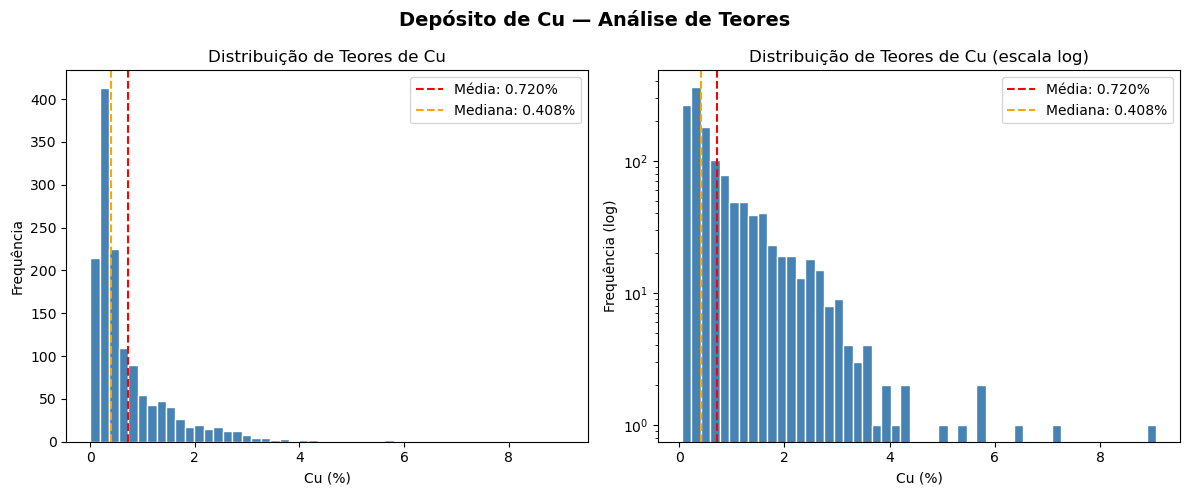

✅ Salvo: histograma_teores.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: escala normal
axes[0].hist(assay['Cu_pct'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Teores de Cu')
axes[0].set_xlabel('Cu (%)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(assay['Cu_pct'].mean(),   color='red',    linestyle='--', label=f"Média: {assay['Cu_pct'].mean():.3f}%")
axes[0].axvline(assay['Cu_pct'].median(), color='orange', linestyle='--', label=f"Mediana: {assay['Cu_pct'].median():.3f}%")
axes[0].legend()

# Gráfico 2: escala logarítmica — padrão em depósitos de Cu
axes[1].hist(assay[assay['Cu_pct'] > 0]['Cu_pct'], bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Distribuição de Teores de Cu (escala log)')
axes[1].set_xlabel('Cu (%)')
axes[1].set_ylabel('Frequência (log)')
axes[1].axvline(assay['Cu_pct'].mean(),   color='red',    linestyle='--', label=f"Média: {assay['Cu_pct'].mean():.3f}%")
axes[1].axvline(assay['Cu_pct'].median(), color='orange', linestyle='--', label=f"Mediana: {assay['Cu_pct'].median():.3f}%")
axes[1].legend()

plt.suptitle('Depósito de Cu — Análise de Teores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'histograma_teores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: histograma_teores.png")

/tmp/ipykernel_218630/451781838.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([norte, sul],


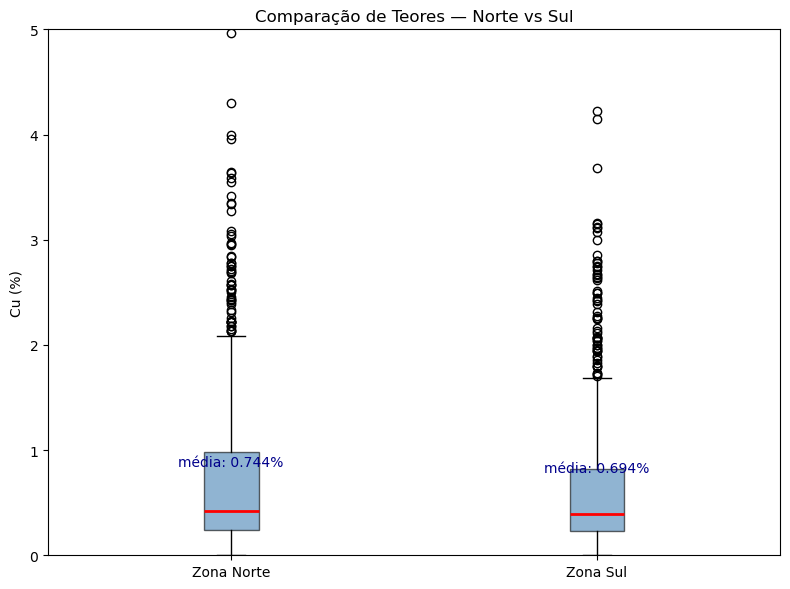

✅ Salvo: boxplot_zonas.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

norte = assay[assay['zone'] == 'Norte']['Cu_pct']
sul   = assay[assay['zone'] == 'Sul']['Cu_pct']

ax.boxplot([norte, sul],
           labels=['Zona Norte', 'Zona Sul'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('Comparação de Teores — Norte vs Sul')
ax.set_ylabel('Cu (%)')
ax.set_ylim(0, 5)  # limita eixo para melhor visualização

# Adiciona médias como texto
ax.text(1, norte.mean() + 0.1, f'média: {norte.mean():.3f}%', ha='center', color='darkblue')
ax.text(2, sul.mean()   + 0.1, f'média: {sul.mean():.3f}%',   ha='center', color='darkblue')

plt.tight_layout()
plt.savefig(OUTPUT + 'boxplot_zonas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: boxplot_zonas.png")

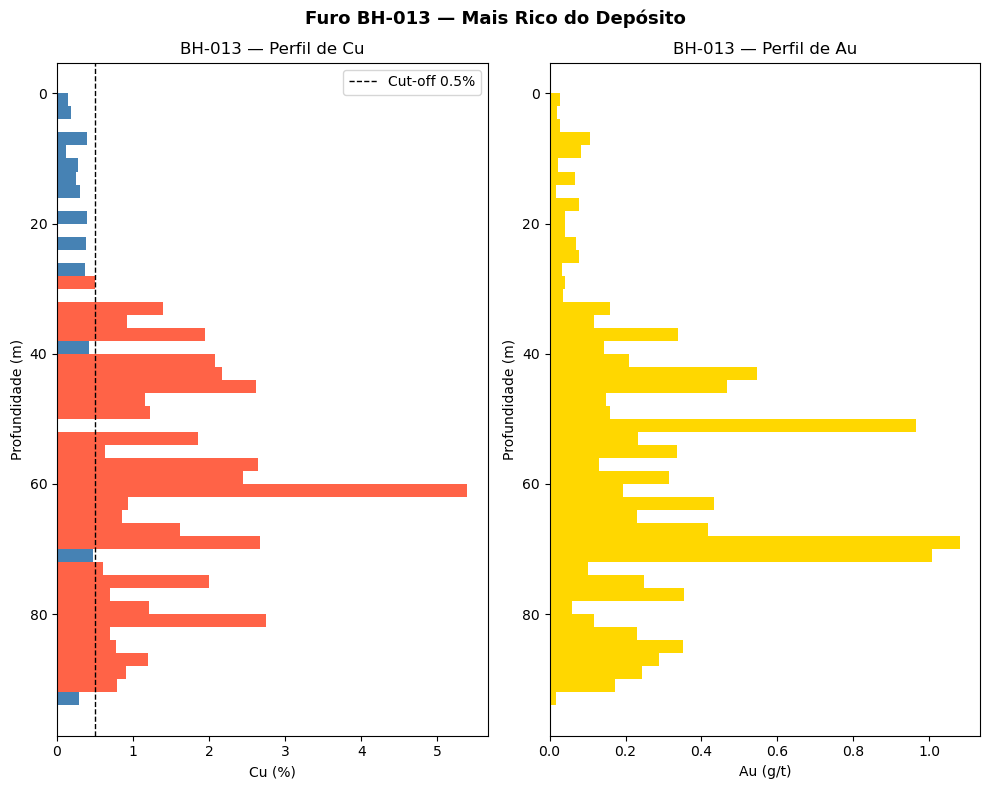

✅ Salvo: perfil_BH013.png


In [4]:
furo = assay[assay['BHID'] == 'BH-013'].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Perfil de Cu
axes[0].barh(furo['FROM'], furo['Cu_pct'], height=furo['LENGTH'],
             color=['tomato' if v >= 0.5 else 'steelblue' for v in furo['Cu_pct']],
             edgecolor='none', align='edge')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Cut-off 0.5%')
axes[0].set_title('BH-013 — Perfil de Cu')
axes[0].set_xlabel('Cu (%)')
axes[0].set_ylabel('Profundidade (m)')
axes[0].invert_yaxis()
axes[0].legend()

# Perfil de Au
axes[1].barh(furo['FROM'], furo['Au_gpt'], height=furo['LENGTH'],
             color='gold', edgecolor='none', align='edge')
axes[1].set_title('BH-013 — Perfil de Au')
axes[1].set_xlabel('Au (g/t)')
axes[1].set_ylabel('Profundidade (m)')
axes[1].invert_yaxis()

plt.suptitle('Furo BH-013 — Mais Rico do Depósito', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'perfil_BH013.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: perfil_BH013.png")

In [5]:
survey = pd.read_csv(DATA + 'survey.csv')

print(f"collar  : {len(collar)} furos")
print(f"survey  : {len(survey)} medições")
print(f"assay   : {len(assay)} intervalos")
print(f"\nColunas collar : {list(collar.columns)}")
print(f"Colunas survey : {list(survey.columns)}")
print(f"Colunas assay  : {list(assay.columns)}")

collar  : 20 furos
survey  : 122 medições
assay   : 1391 intervalos

Colunas collar : ['BHID', 'X', 'Y', 'Z', 'DEPTH', 'COMPANY', 'DATE']
Colunas survey : ['BHID', 'DEPTH', 'DIP', 'AZIMUTH']
Colunas assay  : ['BHID', 'FROM', 'TO', 'Cu_pct', 'Au_gpt', 'zone', 'LENGTH']


In [6]:
# Junta assay com collar pelo BHID
df = assay.merge(collar[['BHID','X','Y','Z','DEPTH','DATE']], on='BHID', how='left')

# Junta com survey — pega o primeiro registro de cada furo (orientação inicial)
survey_resumo = survey.groupby('BHID').agg(
    DIP_medio    = ('DIP',     'mean'),
    AZIMUTH_medio= ('AZIMUTH', 'mean')
).round(1).reset_index()

df = df.merge(survey_resumo, on='BHID', how='left')

print(f"Tabela integrada: {len(df)} intervalos | {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPrimeiras linhas:")
print(df[['BHID','FROM','TO','Cu_pct','X','Y','Z','DIP_medio']].head(6).to_string(index=False))

# Exporta tabela integrada
df.to_csv(OUTPUT + 'furos_integrado.csv', index=False)
print("\n✅ Exportado: furos_integrado.csv")

Tabela integrada: 1391 intervalos | 14 colunas

Colunas: ['BHID', 'FROM', 'TO', 'Cu_pct', 'Au_gpt', 'zone', 'LENGTH', 'X', 'Y', 'Z', 'DEPTH', 'DATE', 'DIP_medio', 'AZIMUTH_medio']

Primeiras linhas:
  BHID  FROM  TO  Cu_pct       X       Y      Z  DIP_medio
BH-001     0   2   0.165 1187.27 2305.93 358.54      -72.5
BH-001     2   4   0.728 1187.27 2305.93 358.54      -72.5
BH-001     4   6   0.870 1187.27 2305.93 358.54      -72.5
BH-001     6   8   0.000 1187.27 2305.93 358.54      -72.5
BH-001     8  10   0.376 1187.27 2305.93 358.54      -72.5
BH-001    10  12   0.060 1187.27 2305.93 358.54      -72.5

✅ Exportado: furos_integrado.csv


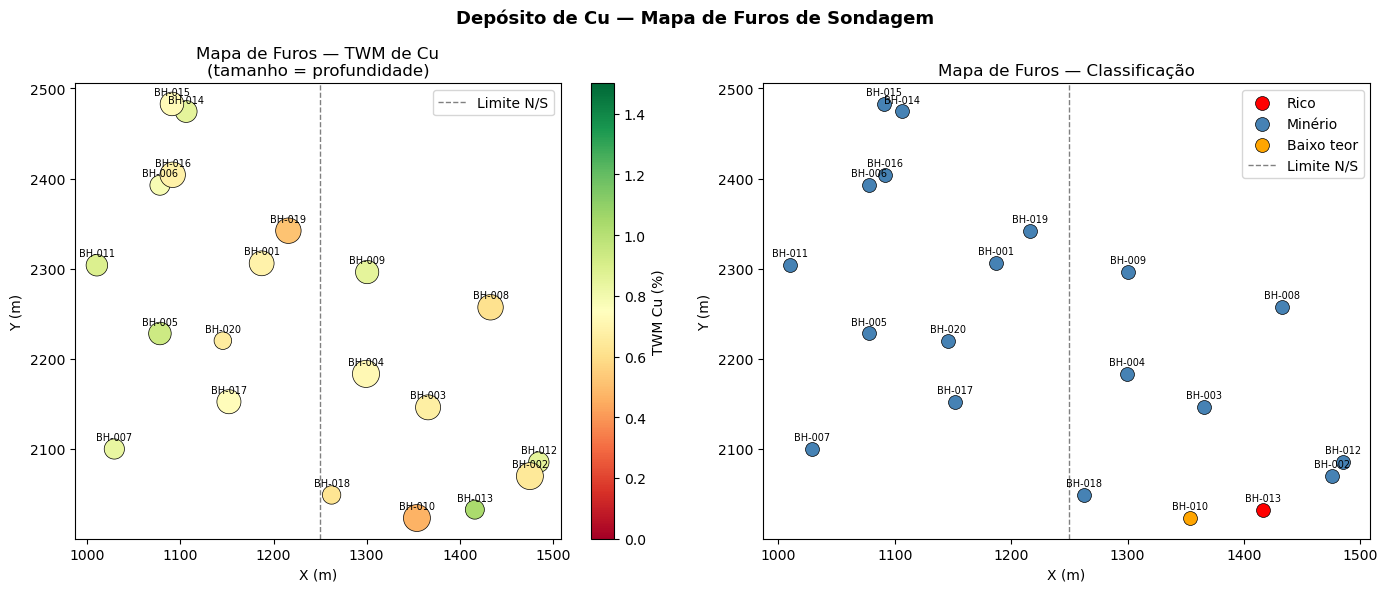

✅ Salvo: mapa_furos.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Mapa 1: localização dos furos coloridos por TWM ──────────────
scatter = axes[0].scatter(
    metricas['X'], metricas['Y'],
    c=metricas['TWM_Cu_pct'],
    cmap='RdYlGn',
    s=metricas['esp_total_m'] * 2,  # tamanho = profundidade do furo
    edgecolors='black', linewidths=0.5,
    vmin=0, vmax=1.5
)
plt.colorbar(scatter, ax=axes[0], label='TWM Cu (%)')

# Nomeia cada furo
for _, row in metricas.iterrows():
    axes[0].annotate(row['BHID'], (row['X'], row['Y']),
                     fontsize=7, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')

axes[0].set_title('Mapa de Furos — TWM de Cu\n(tamanho = profundidade)')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].axvline(1250, color='gray', linestyle='--', linewidth=1, label='Limite N/S')
axes[0].legend()

# ── Mapa 2: localização colorida por classificação ───────────────
cores = {'Rico': 'red', 'Minério': 'steelblue', 'Baixo teor': 'orange', 'Estéril': 'gray'}
for classe, cor in cores.items():
    subset = metricas[metricas['classificacao'] == classe]
    if len(subset) > 0:
        axes[1].scatter(subset['X'], subset['Y'],
                       c=cor, s=100, label=classe,
                       edgecolors='black', linewidths=0.5)

for _, row in metricas.iterrows():
    axes[1].annotate(row['BHID'], (row['X'], row['Y']),
                     fontsize=7, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')

axes[1].set_title('Mapa de Furos — Classificação')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].axvline(1250, color='gray', linestyle='--', linewidth=1, label='Limite N/S')
axes[1].legend()

plt.suptitle('Depósito de Cu — Mapa de Furos de Sondagem', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'mapa_furos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: mapa_furos.png")

In [8]:
# Simula dados de turnos de uma usina de flotação de cobre
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

OUTPUT = '../output/'

np.random.seed(42)
n_turnos = 30

turnos = pd.DataFrame({
    'turno':      [f'T{i:03d}' for i in range(1, n_turnos + 1)],
    'data':       pd.date_range('2024-01-01', periods=n_turnos, freq='8h').strftime('%Y-%m-%d %H:%M'),
    'massa_alim': np.round(np.random.normal(1000, 50, n_turnos), 1),   # toneladas
    'teor_alim':  np.round(np.random.normal(0.72, 0.05, n_turnos), 3), # % Cu alimentação
    'massa_conc': np.round(np.random.normal(45,   3,  n_turnos), 1),   # toneladas concentrado
    'teor_conc':  np.round(np.random.normal(24.5, 1,  n_turnos), 2),   # % Cu concentrado
})

print("=== DADOS DE USINA — PRIMEIROS TURNOS ===")
print(turnos.head(8).to_string(index=False))
print(f"\nTotal de turnos: {len(turnos)}")
print(f"Período: {turnos['data'].iloc[0]} → {turnos['data'].iloc[-1]}")

=== DADOS DE USINA — PRIMEIROS TURNOS ===
turno             data  massa_alim  teor_alim  massa_conc  teor_conc
 T001 2024-01-01 00:00      1024.8      0.690        43.6      24.60
 T002 2024-01-01 08:00       993.1      0.813        44.4      25.47
 T003 2024-01-01 16:00      1032.4      0.719        41.7      23.80
 T004 2024-01-02 00:00      1076.2      0.667        41.4      24.17
 T005 2024-01-02 08:00       988.3      0.761        47.4      24.11
 T006 2024-01-02 16:00       988.3      0.659        49.1      23.04
 T007 2024-01-03 00:00      1079.0      0.730        44.8      24.80
 T008 2024-01-03 08:00      1038.4      0.622        48.0      24.76

Total de turnos: 30
Período: 2024-01-01 00:00 → 2024-01-10 16:00


In [9]:
# ── BALANÇO METALÚRGICO ───────────────────────────────────────────
# Recuperação = (massa_conc × teor_conc) / (massa_alim × teor_alim) × 100
turnos['metal_alim']  = turnos['massa_alim'] * turnos['teor_alim'] / 100  # t Cu na alimentação
turnos['metal_conc']  = turnos['massa_conc'] * turnos['teor_conc'] / 100  # t Cu no concentrado
turnos['metal_rejei'] = turnos['metal_alim'] - turnos['metal_conc']        # t Cu perdido no rejeito

turnos['recuperacao'] = (turnos['metal_conc'] / turnos['metal_alim'] * 100).round(2)
turnos['razao_conc']  = (turnos['massa_alim'] / turnos['massa_conc']).round(2)  # t alim / t conc

print("=== BALANÇO METALÚRGICO POR TURNO ===")
print(turnos[['turno','massa_alim','teor_alim','massa_conc',
              'teor_conc','recuperacao','razao_conc']].to_string(index=False))

=== BALANÇO METALÚRGICO POR TURNO ===
turno  massa_alim  teor_alim  massa_conc  teor_conc  recuperacao  razao_conc
 T001      1024.8      0.690        43.6      24.60       151.68       23.50
 T002       993.1      0.813        44.4      25.47       140.06       22.37
 T003      1032.4      0.719        41.7      23.80       133.70       24.76
 T004      1076.2      0.667        41.4      24.17       139.40       26.00
 T005       988.3      0.761        47.4      24.11       151.95       20.85
 T006       988.3      0.659        49.1      23.04       173.70       20.13
 T007      1079.0      0.730        44.8      24.80       141.05       24.08
 T008      1038.4      0.622        48.0      24.76       184.01       21.63
 T009       976.5      0.654        46.1      24.51       176.93       21.18
 T010      1027.1      0.730        43.1      24.27       139.51       23.83
 T011       976.8      0.757        46.1      23.08       143.89       21.19
 T012       976.7      0.729        49

In [10]:
print("=== RESUMO DO PERÍODO ===")
print(f"Alimentação total    : {turnos['massa_alim'].sum():.1f} t")
print(f"Concentrado total    : {turnos['massa_conc'].sum():.1f} t")
print(f"Metal alimentado     : {turnos['metal_alim'].sum():.2f} t Cu")
print(f"Metal recuperado     : {turnos['metal_conc'].sum():.2f} t Cu")
print(f"Metal perdido        : {turnos['metal_rejei'].sum():.2f} t Cu")
print(f"\nRecuperação média    : {turnos['recuperacao'].mean():.2f}%")
print(f"Recuperação mínima   : {turnos['recuperacao'].min():.2f}% (turno {turnos.loc[turnos['recuperacao'].idxmin(),'turno']})")
print(f"Recuperação máxima   : {turnos['recuperacao'].max():.2f}% (turno {turnos.loc[turnos['recuperacao'].idxmax(),'turno']})")
print(f"\nRazão de concentração: {turnos['razao_conc'].mean():.1f}:1")
print(f"Teor médio concentrado: {turnos['teor_conc'].mean():.2f}% Cu")

# Turnos abaixo de 85% de recuperação — alerta operacional
alertas = turnos[turnos['recuperacao'] < 85]
print(f"\n⚠️  Turnos abaixo de 85% recuperação: {len(alertas)}")
if len(alertas) > 0:
    print(alertas[['turno','data','recuperacao']].to_string(index=False))

=== RESUMO DO PERÍODO ===
Alimentação total    : 29718.0 t
Concentrado total    : 1351.1 t
Metal alimentado     : 212.26 t Cu
Metal recuperado     : 330.64 t Cu
Metal perdido        : -118.39 t Cu

Recuperação média    : 156.80%
Recuperação mínima   : 126.63% (turno T021)
Recuperação máxima   : 184.76% (turno T014)

Razão de concentração: 22.1:1
Teor médio concentrado: 24.48% Cu

⚠️  Turnos abaixo de 85% recuperação: 0


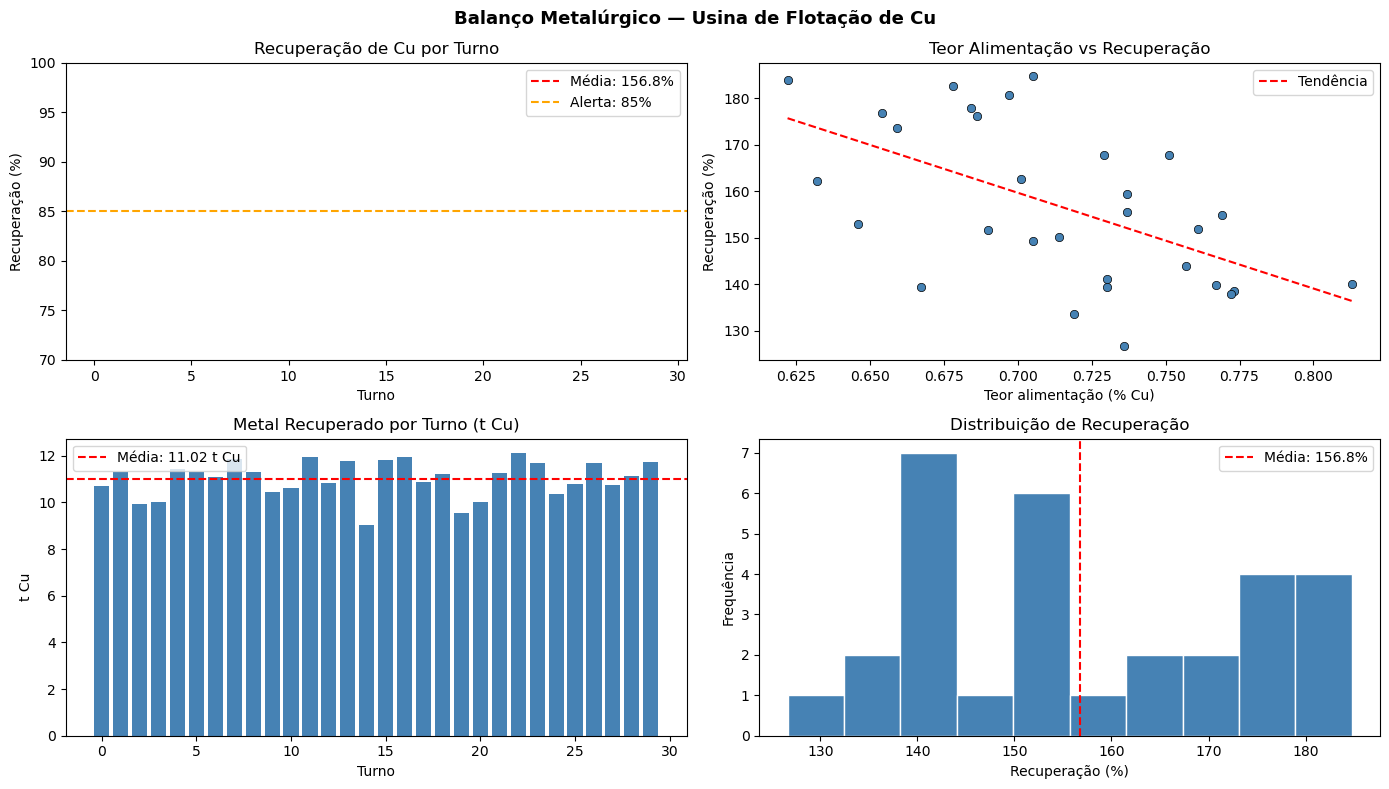

✅ Salvos: balanco_metalurgico.png e balanco_metalurgico.csv


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Gráfico 1: recuperação por turno
axes[0,0].plot(range(len(turnos)), turnos['recuperacao'],
               color='steelblue', linewidth=1.5, marker='o', markersize=4)
axes[0,0].axhline(turnos['recuperacao'].mean(), color='red',
                   linestyle='--', label=f"Média: {turnos['recuperacao'].mean():.1f}%")
axes[0,0].axhline(85, color='orange', linestyle='--', label='Alerta: 85%')
axes[0,0].set_title('Recuperação de Cu por Turno')
axes[0,0].set_xlabel('Turno')
axes[0,0].set_ylabel('Recuperação (%)')
axes[0,0].legend()
axes[0,0].set_ylim(70, 100)

# Gráfico 2: teor alimentação vs recuperação
axes[0,1].scatter(turnos['teor_alim'], turnos['recuperacao'],
                   color='steelblue', edgecolors='black', linewidths=0.5)
axes[0,1].set_title('Teor Alimentação vs Recuperação')
axes[0,1].set_xlabel('Teor alimentação (% Cu)')
axes[0,1].set_ylabel('Recuperação (%)')

# Linha de tendência
z = np.polyfit(turnos['teor_alim'], turnos['recuperacao'], 1)
p = np.poly1d(z)
x_line = np.linspace(turnos['teor_alim'].min(), turnos['teor_alim'].max(), 100)
axes[0,1].plot(x_line, p(x_line), color='red', linestyle='--', label='Tendência')
axes[0,1].legend()

# Gráfico 3: metal recuperado por turno
axes[1,0].bar(range(len(turnos)), turnos['metal_conc'],
               color='steelblue', edgecolor='none')
axes[1,0].axhline(turnos['metal_conc'].mean(), color='red',
                   linestyle='--', label=f"Média: {turnos['metal_conc'].mean():.2f} t Cu")
axes[1,0].set_title('Metal Recuperado por Turno (t Cu)')
axes[1,0].set_xlabel('Turno')
axes[1,0].set_ylabel('t Cu')
axes[1,0].legend()

# Gráfico 4: distribuição de recuperação
axes[1,1].hist(turnos['recuperacao'], bins=10,
                color='steelblue', edgecolor='white')
axes[1,1].axvline(turnos['recuperacao'].mean(), color='red',
                   linestyle='--', label=f"Média: {turnos['recuperacao'].mean():.1f}%")
axes[1,1].set_title('Distribuição de Recuperação')
axes[1,1].set_xlabel('Recuperação (%)')
axes[1,1].set_ylabel('Frequência')
axes[1,1].legend()

plt.suptitle('Balanço Metalúrgico — Usina de Flotação de Cu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'balanco_metalurgico.png', dpi=150, bbox_inches='tight')
plt.show()

# Exporta tabela
turnos.to_csv(OUTPUT + 'balanco_metalurgico.csv', index=False)
print("✅ Salvos: balanco_metalurgico.png e balanco_metalurgico.csv")

In [12]:
# ── CORREÇÃO DO BALANÇO ───────────────────────────────────────────
# metal = massa × (teor/100) → converte % para fração decimal

turnos['metal_alim']  = turnos['massa_alim'] * (turnos['teor_alim'] / 100)
turnos['metal_conc']  = turnos['massa_conc'] * (turnos['teor_conc'] / 100)
turnos['metal_rejei'] = turnos['metal_alim'] - turnos['metal_conc']

# Recuperação correta
turnos['recuperacao'] = (turnos['metal_conc'] / turnos['metal_alim'] * 100).round(2)
turnos['razao_conc']  = (turnos['massa_alim'] / turnos['massa_conc']).round(2)

print("=== BALANÇO CORRIGIDO — PRIMEIROS TURNOS ===")
print(turnos[['turno','metal_alim','metal_conc','metal_rejei','recuperacao']].head(8).round(3).to_string(index=False))

print(f"\n=== RESUMO CORRIGIDO ===")
print(f"Metal alimentado  : {turnos['metal_alim'].sum():.2f} t Cu")
print(f"Metal recuperado  : {turnos['metal_conc'].sum():.2f} t Cu")
print(f"Metal perdido     : {turnos['metal_rejei'].sum():.2f} t Cu")
print(f"Recuperação média : {turnos['recuperacao'].mean():.2f}%")
print(f"\nTurno pior  : {turnos.loc[turnos['recuperacao'].idxmin(),'turno']} — {turnos['recuperacao'].min():.2f}%")
print(f"Turno melhor: {turnos.loc[turnos['recuperacao'].idxmax(),'turno']} — {turnos['recuperacao'].max():.2f}%")

alertas = turnos[turnos['recuperacao'] < 85]
print(f"\n⚠️  Turnos abaixo de 85%: {len(alertas)}")

=== BALANÇO CORRIGIDO — PRIMEIROS TURNOS ===
turno  metal_alim  metal_conc  metal_rejei  recuperacao
 T001       7.071      10.726       -3.654       151.68
 T002       8.074      11.309       -3.235       140.06
 T003       7.423       9.925       -2.502       133.70
 T004       7.178      10.006       -2.828       139.40
 T005       7.521      11.428       -3.907       151.95
 T006       6.513      11.313       -4.800       173.70
 T007       7.877      11.110       -3.234       141.05
 T008       6.459      11.885       -5.426       184.01

=== RESUMO CORRIGIDO ===
Metal alimentado  : 212.26 t Cu
Metal recuperado  : 330.64 t Cu
Metal perdido     : -118.39 t Cu
Recuperação média : 156.80%

Turno pior  : T021 — 126.63%
Turno melhor: T014 — 184.76%

⚠️  Turnos abaixo de 85%: 0


In [13]:
np.random.seed(42)
n_turnos = 30

# Gera alimentação
massa_alim = np.round(np.random.normal(1000, 50, n_turnos), 1)
teor_alim  = np.round(np.random.normal(0.72, 0.05, n_turnos), 3)

# Recuperação REAL entre 82% e 92% — define o processo
recuperacao_real = np.round(np.random.uniform(82, 92, n_turnos), 2)

# Teor do concentrado fixo em torno de 24.5%
teor_conc = np.round(np.random.normal(24.5, 1, n_turnos), 2)

# Calcula massa de concentrado a partir do balanço
# metal_conc = recuperacao × metal_alim
# massa_conc = metal_conc / (teor_conc/100)
metal_alim = massa_alim * teor_alim / 100
metal_conc = recuperacao_real / 100 * metal_alim
massa_conc = np.round(metal_conc / (teor_conc / 100), 1)

turnos = pd.DataFrame({
    'turno':      [f'T{i:03d}' for i in range(1, n_turnos + 1)],
    'data':       pd.date_range('2024-01-01', periods=n_turnos, freq='8h').strftime('%Y-%m-%d %H:%M'),
    'massa_alim': massa_alim,
    'teor_alim':  teor_alim,
    'massa_conc': massa_conc,
    'teor_conc':  teor_conc,
})

# Recalcula balanço
turnos['metal_alim']  = (turnos['massa_alim'] * turnos['teor_alim'] / 100).round(3)
turnos['metal_conc']  = (turnos['massa_conc'] * turnos['teor_conc'] / 100).round(3)
turnos['metal_rejei'] = (turnos['metal_alim'] - turnos['metal_conc']).round(3)
turnos['recuperacao'] = (turnos['metal_conc'] / turnos['metal_alim'] * 100).round(2)
turnos['razao_conc']  = (turnos['massa_alim'] / turnos['massa_conc']).round(2)

print("=== BALANÇO CORRIGIDO ===")
print(turnos[['turno','metal_alim','metal_conc','metal_rejei','recuperacao']].head(8).to_string(index=False))

print(f"\n=== RESUMO ===")
print(f"Metal alimentado  : {turnos['metal_alim'].sum():.2f} t Cu")
print(f"Metal recuperado  : {turnos['metal_conc'].sum():.2f} t Cu")
print(f"Metal perdido     : {turnos['metal_rejei'].sum():.2f} t Cu")
print(f"Recuperação média : {turnos['recuperacao'].mean():.2f}%")
print(f"Turno pior        : {turnos.loc[turnos['recuperacao'].idxmin(),'turno']} — {turnos['recuperacao'].min():.2f}%")
print(f"Turno melhor      : {turnos.loc[turnos['recuperacao'].idxmax(),'turno']} — {turnos['recuperacao'].max():.2f}%")

alertas = turnos[turnos['recuperacao'] < 85]
print(f"\n⚠️  Turnos abaixo de 85%: {len(alertas)}")
if len(alertas) > 0:
    print(alertas[['turno','data','recuperacao']].to_string(index=False))

=== BALANÇO CORRIGIDO ===
turno  metal_alim  metal_conc  metal_rejei  recuperacao
 T001       7.071       6.025        1.046        85.21
 T002       8.074       6.679        1.395        82.72
 T003       7.423       6.328        1.095        85.25
 T004       7.178       6.127        1.051        85.36
 T005       7.521       6.716        0.805        89.30
 T006       6.513       5.756        0.757        88.38
 T007       7.877       7.164        0.713        90.95
 T008       6.459       5.607        0.852        86.81

=== RESUMO ===
Metal alimentado  : 212.25 t Cu
Metal recuperado  : 183.08 t Cu
Metal perdido     : 29.17 t Cu
Recuperação média : 86.26%
Turno pior        : T017 — 82.15%
Turno melhor      : T023 — 91.01%

⚠️  Turnos abaixo de 85%: 9
turno             data  recuperacao
 T002 2024-01-01 08:00        82.72
 T009 2024-01-03 16:00        83.06
 T017 2024-01-06 08:00        82.15
 T018 2024-01-06 16:00        83.02
 T019 2024-01-07 00:00        82.35
 T024 2024-01-08 16

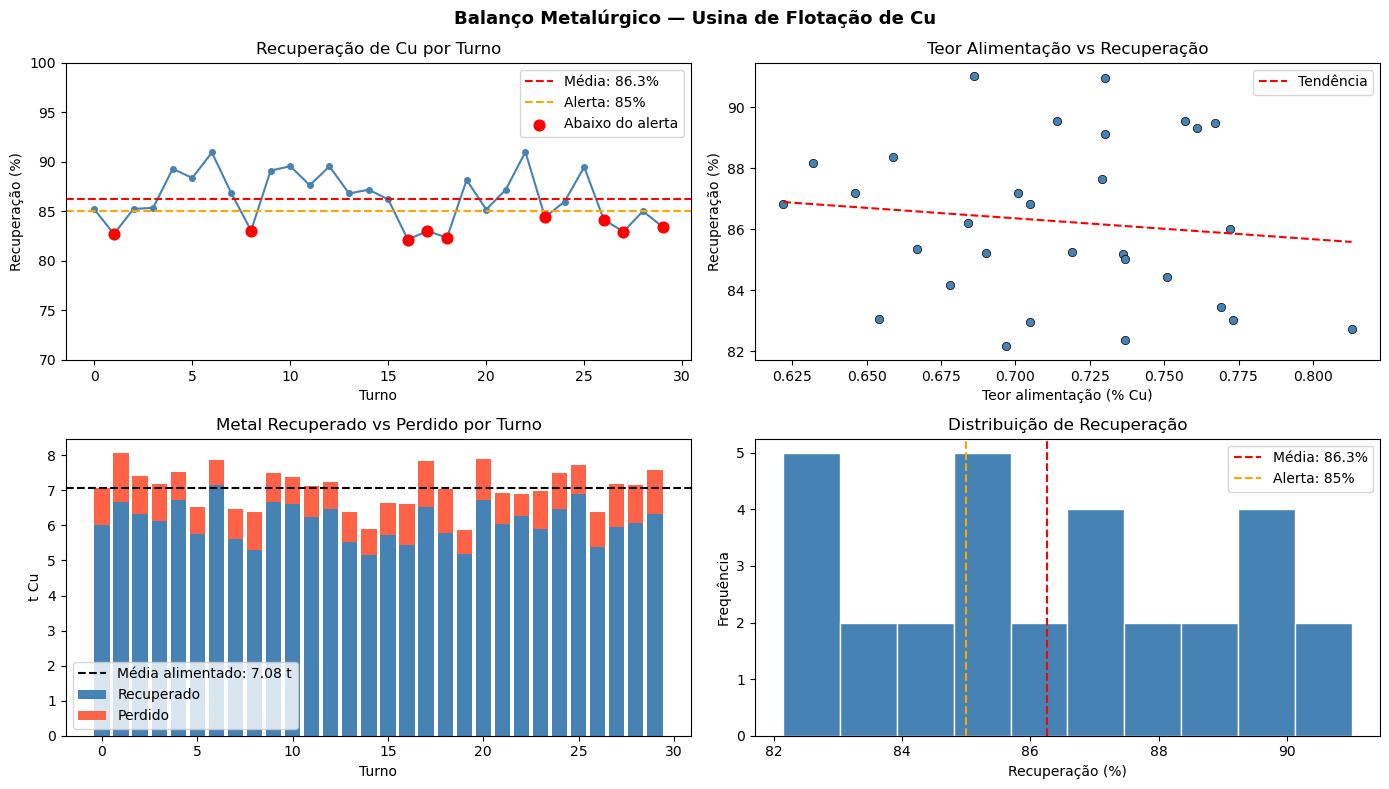

✅ Salvos: balanco_metalurgico.png e balanco_metalurgico.csv


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Gráfico 1: recuperação por turno
axes[0,0].plot(range(len(turnos)), turnos['recuperacao'],
               color='steelblue', linewidth=1.5, marker='o', markersize=4)
axes[0,0].axhline(turnos['recuperacao'].mean(), color='red',
                   linestyle='--', label=f"Média: {turnos['recuperacao'].mean():.1f}%")
axes[0,0].axhline(85, color='orange', linestyle='--', label='Alerta: 85%')

# Marca turnos abaixo do alerta
alertas = turnos[turnos['recuperacao'] < 85]
axes[0,0].scatter(alertas.index, alertas['recuperacao'],
                   color='red', zorder=5, s=60, label='Abaixo do alerta')
axes[0,0].set_title('Recuperação de Cu por Turno')
axes[0,0].set_xlabel('Turno')
axes[0,0].set_ylabel('Recuperação (%)')
axes[0,0].set_ylim(70, 100)
axes[0,0].legend()

# Gráfico 2: teor alimentação vs recuperação
axes[0,1].scatter(turnos['teor_alim'], turnos['recuperacao'],
                   color='steelblue', edgecolors='black', linewidths=0.5)
z = np.polyfit(turnos['teor_alim'], turnos['recuperacao'], 1)
p = np.poly1d(z)
x_line = np.linspace(turnos['teor_alim'].min(), turnos['teor_alim'].max(), 100)
axes[0,1].plot(x_line, p(x_line), color='red', linestyle='--', label='Tendência')
axes[0,1].set_title('Teor Alimentação vs Recuperação')
axes[0,1].set_xlabel('Teor alimentação (% Cu)')
axes[0,1].set_ylabel('Recuperação (%)')
axes[0,1].legend()

# Gráfico 3: metal recuperado vs perdido por turno
x = range(len(turnos))
axes[1,0].bar(x, turnos['metal_conc'],  color='steelblue', label='Recuperado', edgecolor='none')
axes[1,0].bar(x, turnos['metal_rejei'], color='tomato',    label='Perdido',
               bottom=turnos['metal_conc'], edgecolor='none')
axes[1,0].axhline(turnos['metal_alim'].mean(), color='black',
                   linestyle='--', label=f"Média alimentado: {turnos['metal_alim'].mean():.2f} t")
axes[1,0].set_title('Metal Recuperado vs Perdido por Turno')
axes[1,0].set_xlabel('Turno')
axes[1,0].set_ylabel('t Cu')
axes[1,0].legend()

# Gráfico 4: distribuição de recuperação
axes[1,1].hist(turnos['recuperacao'], bins=10,
                color='steelblue', edgecolor='white')
axes[1,1].axvline(turnos['recuperacao'].mean(), color='red',
                   linestyle='--', label=f"Média: {turnos['recuperacao'].mean():.1f}%")
axes[1,1].axvline(85, color='orange', linestyle='--', label='Alerta: 85%')
axes[1,1].set_title('Distribuição de Recuperação')
axes[1,1].set_xlabel('Recuperação (%)')
axes[1,1].set_ylabel('Frequência')
axes[1,1].legend()

plt.suptitle('Balanço Metalúrgico — Usina de Flotação de Cu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'balanco_metalurgico.png', dpi=150, bbox_inches='tight')

# Exporta tabela corrigida
turnos.to_csv(OUTPUT + 'balanco_metalurgico.csv', index=False)

plt.show()
print("✅ Salvos: balanco_metalurgico.png e balanco_metalurgico.csv")

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

DATA   = '../data/'
OUTPUT = '../output/'
os.makedirs(OUTPUT, exist_ok=True)

# Carrega todos os arquivos que produzimos
assay    = pd.read_csv(OUTPUT + 'assay_limpo.csv')
metricas = pd.read_csv(OUTPUT + 'metricas_furos_final.csv')
qaqc     = pd.read_csv(OUTPUT + 'relatorio_qaqc.csv')
balanco  = pd.read_csv(OUTPUT + 'balanco_metalurgico.csv')

print("✅ Arquivos carregados:")
print(f"   assay_limpo        : {len(assay)} intervalos")
print(f"   metricas_furos     : {len(metricas)} furos")
print(f"   relatorio_qaqc     : {len(qaqc)} verificações")
print(f"   balanco_metalurgico: {len(balanco)} turnos")

✅ Arquivos carregados:
   assay_limpo        : 1391 intervalos
   metricas_furos     : 20 furos
   relatorio_qaqc     : 5 verificações
   balanco_metalurgico: 30 turnos


In [2]:
caminho = OUTPUT + 'relatorio_mineracao.xlsx'

with pd.ExcelWriter(caminho, engine='openpyxl') as writer:

    # Aba 1: Resumo executivo
    resumo = pd.DataFrame({
        'indicador': [
            'Total de furos',
            'Total de intervalos',
            'Comprimento total amostrado (m)',
            'Teor médio Cu (%)',
            'Teor médio Au (g/t)',
            'Furos classificados Rico',
            'Furos classificados Minério',
            'Furos classificados Baixo teor',
            'Furos classificados Estéril',
            'Recuperação média usina (%)',
            'Metal alimentado total (t Cu)',
            'Metal recuperado total (t Cu)',
            'Metal perdido total (t Cu)',
        ],
        'valor': [
            metricas['BHID'].nunique(),
            len(assay),
            round((assay['TO'] - assay['FROM']).sum(), 1),
            round(assay['Cu_pct'].mean(), 3),
            round(assay['Au_gpt'].mean(), 4),
            len(metricas[metricas['classificacao'] == 'Rico']),
            len(metricas[metricas['classificacao'] == 'Minério']),
            len(metricas[metricas['classificacao'] == 'Baixo teor']),
            len(metricas[metricas['classificacao'] == 'Estéril']),
            round(balanco['recuperacao'].mean(), 2),
            round(balanco['metal_alim'].sum(), 2),
            round(balanco['metal_conc'].sum(), 2),
            round(balanco['metal_rejei'].sum(), 2),
        ]
    })
    resumo.to_excel(writer, sheet_name='Resumo', index=False)

    # Aba 2: Ranking de furos
    metricas.to_excel(writer, sheet_name='Ranking Furos', index=False)

    # Aba 3: QA/QC
    qaqc.to_excel(writer, sheet_name='QA-QC', index=False)

    # Aba 4: Balanço metalúrgico
    balanco[['turno','data','massa_alim','teor_alim','massa_conc',
             'teor_conc','metal_alim','metal_conc','metal_rejei',
             'recuperacao','razao_conc']].to_excel(
                 writer, sheet_name='Balanço', index=False)

    # Aba 5: Dados de assay limpos
    assay.to_excel(writer, sheet_name='Assay Limpo', index=False)

print("✅ Arquivo criado: relatorio_mineracao.xlsx")
print(f"   Abas: Resumo | Ranking Furos | QA-QC | Balanço | Assay Limpo")

✅ Arquivo criado: relatorio_mineracao.xlsx
   Abas: Resumo | Ranking Furos | QA-QC | Balanço | Assay Limpo


In [3]:
wb = load_workbook(caminho)

# Estilos
header_fill   = PatternFill("solid", fgColor="1F4E79")  # azul escuro
header_font   = Font(color="FFFFFF", bold=True)
rico_fill     = PatternFill("solid", fgColor="C6EFCE")  # verde claro
minerio_fill  = PatternFill("solid", fgColor="DDEBF7")  # azul claro
baixo_fill    = PatternFill("solid", fgColor="FFEB9C")  # amarelo
alerta_fill   = PatternFill("solid", fgColor="FFC7CE")  # vermelho claro
center        = Alignment(horizontal='center', vertical='center')

def formatar_cabecalho(ws):
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = center
    # Ajusta largura das colunas
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = max_len + 4

# Formata todas as abas com cabeçalho
for nome in wb.sheetnames:
    formatar_cabecalho(wb[nome])

# Colore classificações na aba Ranking Furos
ws_rank = wb['Ranking Furos']
col_class = None
for cell in ws_rank[1]:
    if cell.value == 'classificacao':
        col_class = cell.column
        break

if col_class:
    for row in ws_rank.iter_rows(min_row=2):
        val = row[col_class - 1].value
        if val == 'Rico':
            for cell in row: cell.fill = rico_fill
        elif val == 'Minério':
            for cell in row: cell.fill = minerio_fill
        elif val == 'Baixo teor':
            for cell in row: cell.fill = baixo_fill

# Colore turnos abaixo de 85% na aba Balanço
ws_bal = wb['Balanço']
col_rec = None
for cell in ws_bal[1]:
    if cell.value == 'recuperacao':
        col_rec = cell.column
        break

if col_rec:
    for row in ws_bal.iter_rows(min_row=2):
        if row[col_rec - 1].value and row[col_rec - 1].value < 85:
            for cell in row: cell.fill = alerta_fill

wb.save(caminho)
print("✅ Relatório formatado e salvo!")
print(f"   Verde  = Rico")
print(f"   Azul   = Minério")
print(f"   Amarelo = Baixo teor")
print(f"   Vermelho = Turnos abaixo de 85% recuperação")

✅ Relatório formatado e salvo!
   Verde  = Rico
   Azul   = Minério
   Amarelo = Baixo teor
   Vermelho = Turnos abaixo de 85% recuperação
